In [ ]:
!pip install -U kagglehub

In [59]:
import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from PIL import Image
from sklearn.model_selection import train_test_split
import torch.nn as nn
from google.colab import files

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Seed:", SEED)

Seed: 42


In [ ]:
dataset_path = kagglehub.dataset_download(
    "shreyanmohanty/chest-x-ray-dataset-for-pneumonia-classification"
)

print("Dataset path:")
print(dataset_path)

100%|██████████| 128M/128M [00:06<00:00, 20.2MB/s]

Extracting files...


Dataset path:
/root/.cache/kagglehub/datasets/shreyanmohanty/chest-x-ray-dataset-for-pneumonia-classification/versions/1


In [ ]:
dataset_path = Path(dataset_path)

print(dataset_path)

/root/.cache/kagglehub/datasets/shreyanmohanty/chest-x-ray-dataset-for-pneumonia-classification/versions/1


In [ ]:
for item in dataset_path.iterdir():
    print(item.name)

test
train


In [ ]:
for root, dirs, files in os.walk(dataset_path):
  level = root.replace(str(dataset_path), "").count(os.sep)
  indent = "    " * level
  print(f"{indent}{os.path.basename(root)}/")

  if level >= 2:
    dirs[:] = []

  for file in files[:5]:
    print(f"{indent}      {file}")

1/
    test/
        BACTERIAL_PNEUMONIA/
              person159_bacteria_747_jpeg.rf.198257edcfc9c59a9954708b628abf48.jpg
              person142_bacteria_684_jpeg.rf.8cd333675440d4d8ad73a5277e5ef3c5.jpg
              person80_bacteria_390_jpeg.rf.9697104c753d1fb9b345fe37a5aeed5b.jpg
              person114_bacteria_544_jpeg.rf.c6434d59ea7ab88f31233166e086d958.jpg
              person91_bacteria_449_jpeg.rf.67a1c3e47c413773d6f6868b3844dff5.jpg
        VIRAL_PNEUMONIA/
              person48_virus_100_jpeg.rf.1af345233718a3fd61ba42576b1eefea.jpg
              person44_virus_93_jpeg.rf.9a36f6cc801b3269a5b6e5836a9fc14f.jpg
              person39_virus_85_jpeg.rf.24c73d5d895071d9757f20330feb32ba.jpg
              person75_virus_136_jpeg.rf.fa110a0519348829a914b7c1e722ccde.jpg
              person1_virus_7_jpeg.rf.0c278831f3693e6784e696bfba7f546c.jpg
        NORMAL/
              IM-0050-0001_jpeg.rf.72e78a2f49cc30dc3539eba200a1a7f3.jpg
              IM-0099-0001_jpeg.rf.e681be8090366049a

In [ ]:
all_dirs = [
    path for path in dataset_path.rglob("*")
    if path.is_dir()
]

for path in all_dirs:
    print(path)

/root/.cache/kagglehub/datasets/shreyanmohanty/chest-x-ray-dataset-for-pneumonia-classification/versions/1/test
/root/.cache/kagglehub/datasets/shreyanmohanty/chest-x-ray-dataset-for-pneumonia-classification/versions/1/train
/root/.cache/kagglehub/datasets/shreyanmohanty/chest-x-ray-dataset-for-pneumonia-classification/versions/1/test/BACTERIAL_PNEUMONIA
/root/.cache/kagglehub/datasets/shreyanmohanty/chest-x-ray-dataset-for-pneumonia-classification/versions/1/test/VIRAL_PNEUMONIA
/root/.cache/kagglehub/datasets/shreyanmohanty/chest-x-ray-dataset-for-pneumonia-classification/versions/1/test/NORMAL
/root/.cache/kagglehub/datasets/shreyanmohanty/chest-x-ray-dataset-for-pneumonia-classification/versions/1/train/BACTERIAL_PNEUMONIA
/root/.cache/kagglehub/datasets/shreyanmohanty/chest-x-ray-dataset-for-pneumonia-classification/versions/1/train/VIRAL_PNEUMONIA
/root/.cache/kagglehub/datasets/shreyanmohanty/chest-x-ray-dataset-for-pneumonia-classification/versions/1/train/NORMAL


In [ ]:
image_extensions = {
    ".jpg",
    ".jpeg",
    ".png"
}

image_files = [
    path
    for path in dataset_path.rglob("*")
    if path.is_file()
    and path.suffix.lower() in image_extensions
]

print("Total images:", len(image_files))

Total images: 16236


In [ ]:
for path in image_files[:10]:
  print(path)

/root/.cache/kagglehub/datasets/shreyanmohanty/chest-x-ray-dataset-for-pneumonia-classification/versions/1/train/BACTERIAL_PNEUMONIA/person58_bacteria_275_jpeg.rf.9f784a89f2f724389017af48edea06b5.jpg
/root/.cache/kagglehub/datasets/shreyanmohanty/chest-x-ray-dataset-for-pneumonia-classification/versions/1/train/BACTERIAL_PNEUMONIA/person680_bacteria_2575_jpeg.rf.3f6236b7ea9313b07133ba3725f38cea.jpg
/root/.cache/kagglehub/datasets/shreyanmohanty/chest-x-ray-dataset-for-pneumonia-classification/versions/1/train/BACTERIAL_PNEUMONIA/person1265_bacteria_3223_jpeg.rf.d2da98c599779cf2573d571def4c2733.jpg
/root/.cache/kagglehub/datasets/shreyanmohanty/chest-x-ray-dataset-for-pneumonia-classification/versions/1/train/BACTERIAL_PNEUMONIA/person1634_bacteria_4334_jpeg.rf.f023709019e169b00e236be20009c7c0.jpg
/root/.cache/kagglehub/datasets/shreyanmohanty/chest-x-ray-dataset-for-pneumonia-classification/versions/1/train/BACTERIAL_PNEUMONIA/person337_bacteria_1564_jpeg.rf.3f9b2370637a4785e9de27533a4

In [ ]:
class_counts = {}

for path in image_files:

    class_name = path.parent.name

    class_counts[class_name] = (
        class_counts.get(class_name, 0) + 1
    )

class_counts

{'BACTERIAL_PNEUMONIA': 7800, 'VIRAL_PNEUMONIA': 4161, 'NORMAL': 4275}

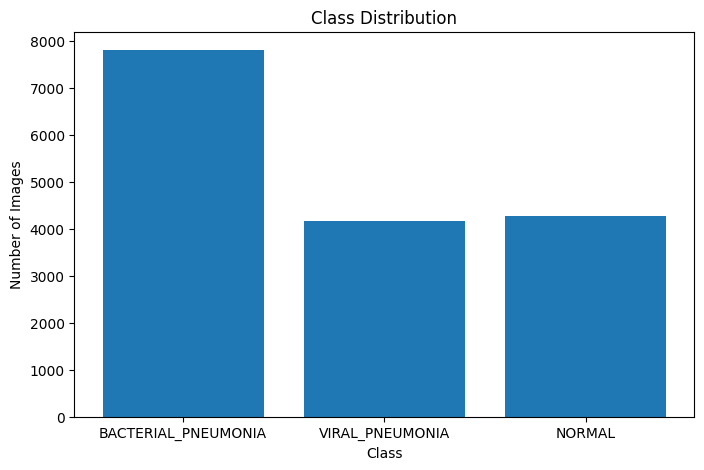

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

plt.show()

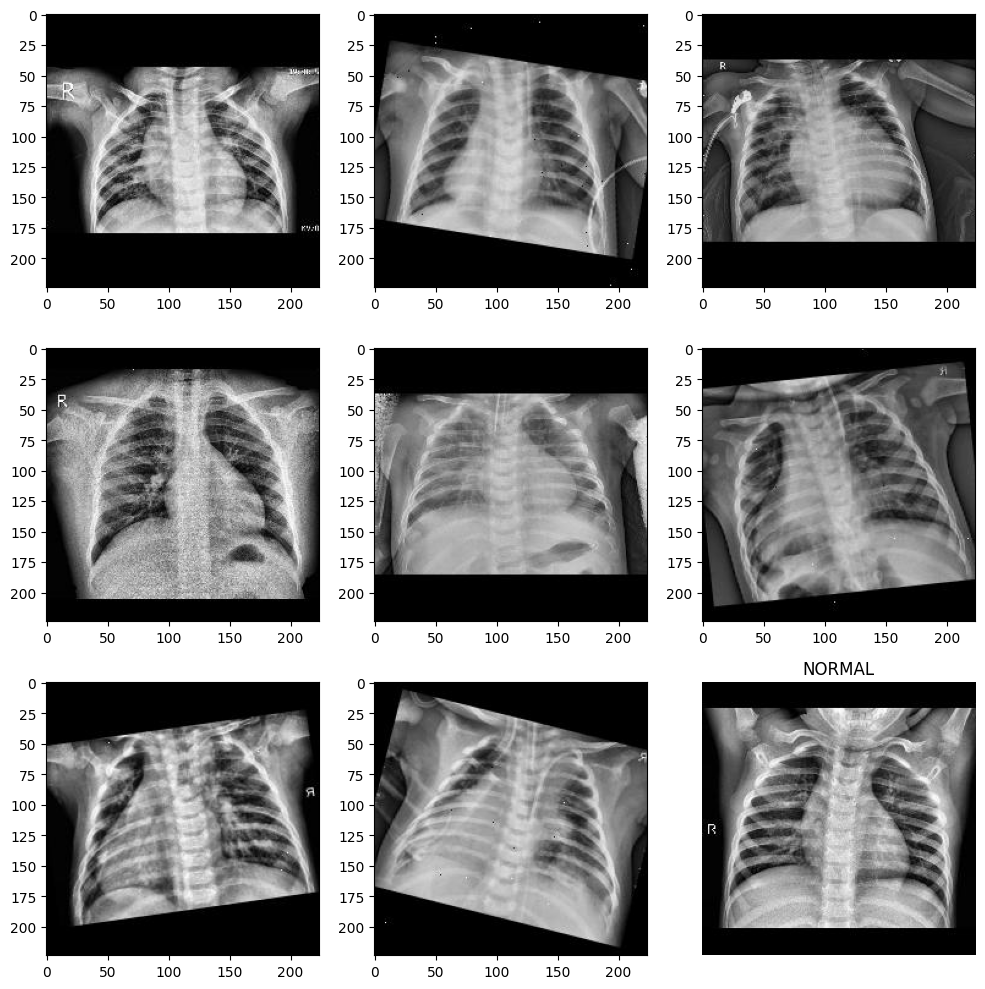

In [ ]:
sample_images = random.sample(
    image_files,
    min(9, len(image_files))
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(10, 10)
)

for ax, image_path in zip(axes.ravel(), sample_images):
    img = plt.imread(image_path)

    image = plt.imread(image_path)
    ax.imshow(image, cmap="gray")

ax.set_title(
    image_path.parent.name
)

ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
image_sizes = []

for path in image_files[:100]:

    with Image.open(path) as image:
        image_sizes.append(image.size)

image_sizes[:10]

[(224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224),
 (224, 224)]

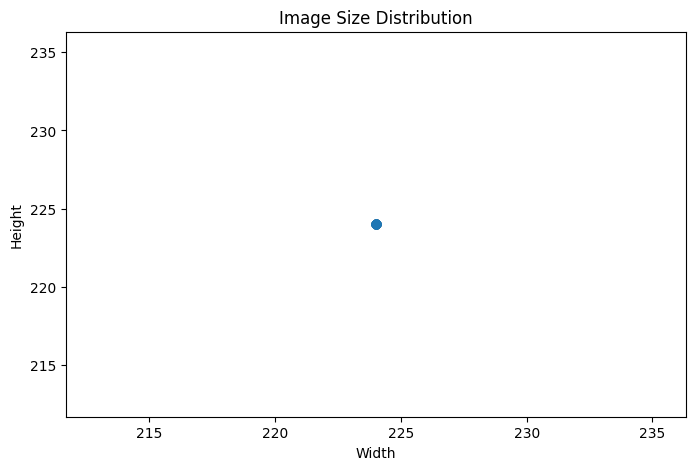

In [ ]:
widths = [size[0] for size in image_sizes]
heights = [size[1] for size in image_sizes]

plt.figure(figsize=(8, 5))
plt.scatter(
    widths,
    heights,
    alpha=0.5
)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")

plt.show()

In [ ]:
classes = sorted(
    class_counts.keys()
)

class_to_idx = {
    class_name: index
    for index, class_name in enumerate(classes)
}

idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}

print("Classes:", classes)
print("Class mapping:", class_to_idx)

Classes: ['BACTERIAL_PNEUMONIA', 'NORMAL', 'VIRAL_PNEUMONIA']
Class mapping: {'BACTERIAL_PNEUMONIA': 0, 'NORMAL': 1, 'VIRAL_PNEUMONIA': 2}


In [ ]:
data = pd.DataFrame({
    "path": [
        str(path)
        for path in image_files
    ],
    "class_name": [
        path.parent.name
        for path in image_files
    ]
})

data["label"] = data["class_name"].map(class_to_idx)

data.head()

,path,class_name,label
0,/root/.cache/kagglehub/datasets/shreyanmohanty...,BACTERIAL_PNEUMONIA,0
1,/root/.cache/kagglehub/datasets/shreyanmohanty...,BACTERIAL_PNEUMONIA,0
2,/root/.cache/kagglehub/datasets/shreyanmohanty...,BACTERIAL_PNEUMONIA,0
3,/root/.cache/kagglehub/datasets/shreyanmohanty...,BACTERIAL_PNEUMONIA,0
4,/root/.cache/kagglehub/datasets/shreyanmohanty...,BACTERIAL_PNEUMONIA,0


In [ ]:
print("Total images:", len(data))

print("\nClass distribution:")
print(
    data["class_name"].value_counts()
)

Total images: 16236

Class distribution:
class_name
BACTERIAL_PNEUMONIA    7800
NORMAL                 4275
VIRAL_PNEUMONIA        4161
Name: count, dtype: int64


In [ ]:
train_files = [
    path
    for path in image_files
    if "train" in path.parts
]

test_files = [
    path
    for path in image_files
    if "test" in path.parts
]

print("Train images:", len(train_files))
print("Test images:", len(test_files))

Train images: 15618
Test images: 618


In [ ]:
train_data = pd.DataFrame({
    "path": [
        str(path)
        for path in train_files
    ],
    "class_name": [
        path.parent.name
        for path in train_files
    ]
})

test_data = pd.DataFrame({
    "path": [
        str(path)
        for path in test_files
    ],
    "class_name": [
        path.parent.name
        for path in test_files
    ]
})

train_data["label"] = train_data["class_name"].map(class_to_idx)
test_data["label"] = test_data["class_name"].map(class_to_idx)

In [ ]:
train_data, val_data = train_test_split(
    train_data,
    test_size=0.2,
    stratify=train_data["label"],
    random_state=SEED
)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 12494
Validation: 3124
Test: 618


In [ ]:
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

In [ ]:
val_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

In [ ]:
class PneumoniaDataset(torch.utils.data.Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)

        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        image_path = self.dataframe.loc[index, "path"]

        label = self.dataframe.loc[index, "label"]

        image = Image.open(image_path).convert("L")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
train_dataset = PneumoniaDataset(train_data, transform=train_transforms)

val_dataset = PneumoniaDataset(val_data, transform=val_test_transforms)

test_dataset = PneumoniaDataset(test_data, transform=val_test_transforms)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 12494
Validation: 3124
Test: 618


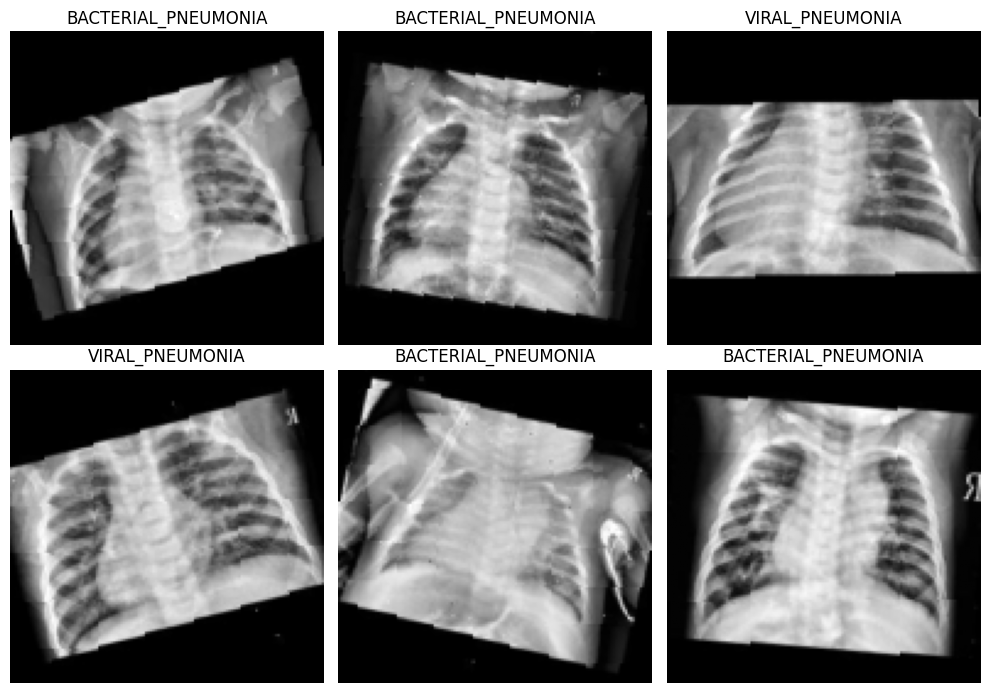

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for ax in axes.ravel():
    index = random.randint(0, len(train_dataset) - 1)

    image, label = train_dataset[index]

    ax.imshow(image[0], cmap="gray")

    ax.set_title(idx_to_class[label.item()])

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
batch_size = 32
num_workers = 2

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

In [ ]:
images, labels = next(
    iter(train_loader)
)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 1, 128, 128])
Labels shape: torch.Size([32])


In [ ]:
class PneumoniaCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(
                (1, 1)
            ),
            nn.Flatten(),
            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x

In [ ]:
model = PneumoniaCNN(num_classes=len(classes))

print(model)

PneumoniaCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [ ]:
device = torch.device("cpu")

model = model.to(device)

print("Device:", device)

Device: cpu


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [ ]:
num_epochs = 3

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/3] Train Loss: 0.8373 Train Acc: 0.6106 Val Loss: 0.7524 Val Acc: 0.6658
Epoch [2/3] Train Loss: 0.7383 Train Acc: 0.6554 Val Loss: 0.7232 Val Acc: 0.6812
Epoch [3/3] Train Loss: 0.7078 Train Acc: 0.6826 Val Loss: 0.6921 Val Acc: 0.6882


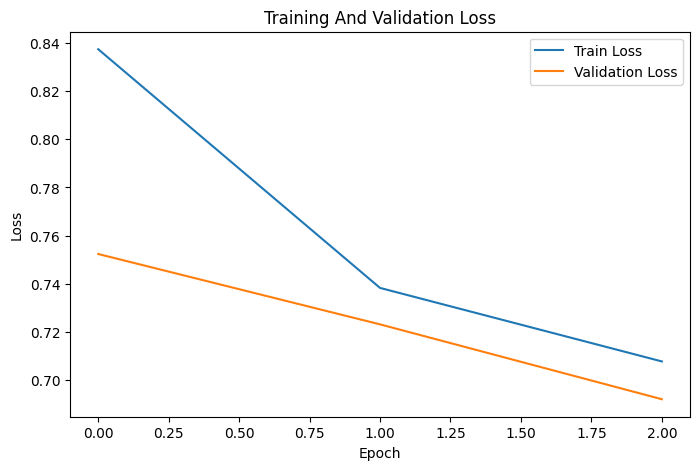

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    train_losses,
    label="Train Loss"
)
plt.plot(
    val_losses,
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training And Validation Loss")
plt.legend()
plt.show()

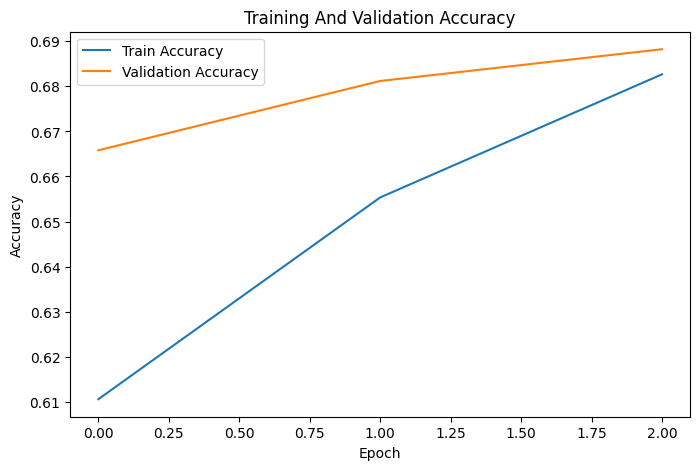

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    train_accuracies,
    label="Train Accuracy"
)
plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training And Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
model.eval()

all_predictions = []
all_labels = []

In [ ]:
with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    outputs = model(images)
    predictions = outputs.argmax(dim=1)

    all_predictions.extend(predictions.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

In [ ]:
accuracy = accuracy_score(all_labels, all_predictions)

prediction = precision_score(all_labels, all_predictions, average="weighted", zero_division=0)

recall = recall_score(all_labels, all_predictions, average="weighted", zero_division=0)

f1 = f1_score(all_labels, all_predictions, average="weighted", zero_division=0)

In [ ]:
cm = confusion_matrix(all_labels, all_predictions)

print(cm)

[[240   0   0]
 [214   0  17]
 [134   0  13]]


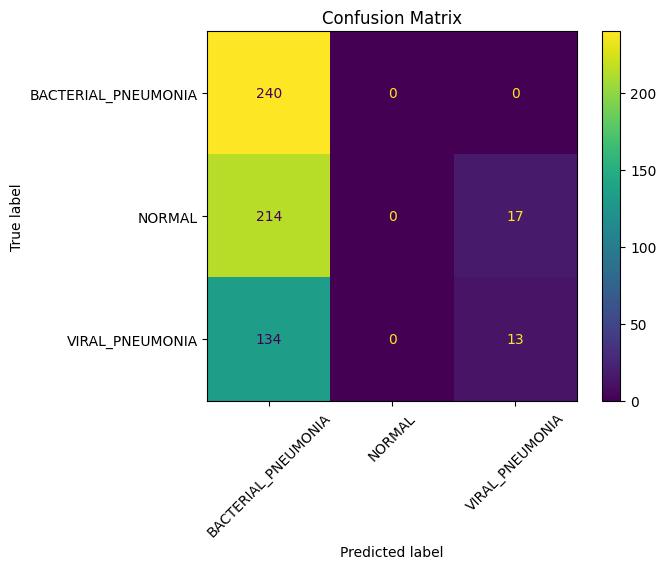

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    xticks_rotation=45
)

plt.title(
    "Confusion Matrix"
)

plt.show()

In [53]:
def predict_image(model, image_path, transform, classes):
  model.eval()

  image = Image.open(image_path).convert("L")
  transformed_image = transform(image)

  input_tensor = transformed_image.unsqueeze(0)

  with torch.no_grad():
    output = model(input_tensor)

  class_probabilities = torch.softmax(output, dim=1)

  predicted_class_idx = class_probabilities.argmax(dim=1).item()

  return classes[predicted_class_idx], class_probabilities[0].numpy()

In [54]:
sample_path = test_data.iloc[0]["path"]

prediction, probabilities = predict_image(
    model,
    sample_path,
    val_test_transforms,
    classes
)

print("Image:", sample_path)
print("Prediction:", prediction)
print("Probabilities:", probabilities)

Image: /root/.cache/kagglehub/datasets/shreyanmohanty/chest-x-ray-dataset-for-pneumonia-classification/versions/1/test/BACTERIAL_PNEUMONIA/person159_bacteria_747_jpeg.rf.198257edcfc9c59a9954708b628abf48.jpg
Prediction: BACTERIAL_PNEUMONIA
Probabilities: [0.7758297  0.00304215 0.22112815]


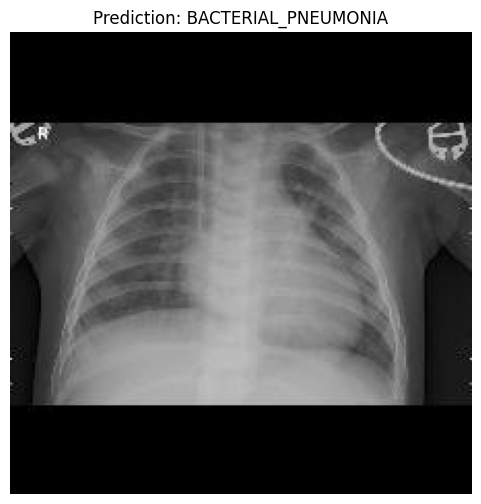

In [55]:
image = Image.open(sample_path).convert("L")

plt.figure(figsize=(6, 6))

plt.imshow(image, cmap="gray")

plt.title(f"Prediction: {prediction}")

plt.axis("off")

plt.show()

In [56]:
torch.save(model.state_dict(), "pneumonia_cnn.pth")
print("Model saved successfully.")

Model saved successfully.


In [60]:
files.download("pneumonia_cnn.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>